# Evaluation Notebook
Evaluates the recommendation system using Precision@5, Recall@5, and F1 Score.

In [12]:
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

API_URL = "http://localhost:8000/recommend"

# 20 test queries and their expected target categories
test_cases = [
    {"query": "gaming laptop with fast graphics", "expected_category": "Electronics"},
    {"query": "wireless noise cancelling headphones", "expected_category": "Electronics"},
    {"query": "green tea for weight loss", "expected_category": "Groceries"},
    {"query": "yoga mat extra thick", "expected_category": "Sports & Outdoors"},
    {"query": "comfortable running shoes", "expected_category": "Footwear"},
    {"query": "latest 5g smartphone", "expected_category": "Electronics"},
    {"query": "insulated water bottle", "expected_category": "Kitchenware"},
    {"query": "adjustable dumbbells", "expected_category": "Sports & Outdoors"},
    {"query": "ergonomic office chair", "expected_category": "Furniture"},
    {"query": "vitamin c serum", "expected_category": "Beauty & Personal Care"},
    {"query": "budget gaming mouse", "expected_category": "Gaming & Accessories"},
    {"query": "sterling silver necklace", "expected_category": "Jewelry"},
    {"query": "waterproof bluetooth speaker", "expected_category": "Electronics"},
    {"query": "whey protein powder", "expected_category": "Healthcare & Wellness"},
    {"query": "classic hardcover novel", "expected_category": "Books"},
    {"query": "high end gaming pc", "expected_category": "Electronics"},
    {"query": "gym equipment for home", "expected_category": "Sports & Outdoors"},
    {"query": "healthy drink", "expected_category": "Groceries"},
    {"query": "skincare for glowing skin", "expected_category": "Beauty & Personal Care"},
    {"query": "study desk chair", "expected_category": "Furniture"}
]

In [13]:
def evaluate_queries():
    precisions = []
    recalls = []
    f1_scores = []
    queries = []
    
    # Assuming we have 3 relevant items for each category max in our dummy dataset
    # In reality, recall denominator should be actual number of relevant items in the whole DB
    TOTAL_RELEVANT = 3 
    
    for i, test in enumerate(test_cases):
        payload = {"query": test['query'], "top_k": 5}
        try:
            resp = requests.post(API_URL, json=payload)
            resp.raise_for_status()
            data = resp.json()
            products = data.get('products', [])
            
            relevant_retrieved = sum(1 for p in products if p['category'] == test['expected_category'])
            
            precision_at_5 = relevant_retrieved / 5.0
            recall_at_5 = relevant_retrieved / TOTAL_RELEVANT
            
            f1 = 0 if (precision_at_5 + recall_at_5) == 0 else \
                 (2 * precision_at_5 * recall_at_5) / (precision_at_5 + recall_at_5)
            
            precisions.append(precision_at_5)
            recalls.append(recall_at_5)
            f1_scores.append(f1)
            queries.append(f"Q{i+1}")
            
        except Exception as e:
            print(f"Error on query {test['query']}: {e}")
            precisions.append(0)
            recalls.append(0)
            f1_scores.append(0)
            queries.append(f"Q{i+1}")
            
    return queries, precisions, recalls, f1_scores

queries, precisions, recalls, f1_scores = evaluate_queries()

print("Average Precision@5:", np.mean(precisions))
print("Average Recall@5:", np.mean(recalls))
print("Average F1 Score:", np.mean(f1_scores))

Average Precision@5: 0.5
Average Recall@5: 0.8333333333333334
Average F1 Score: 0.625


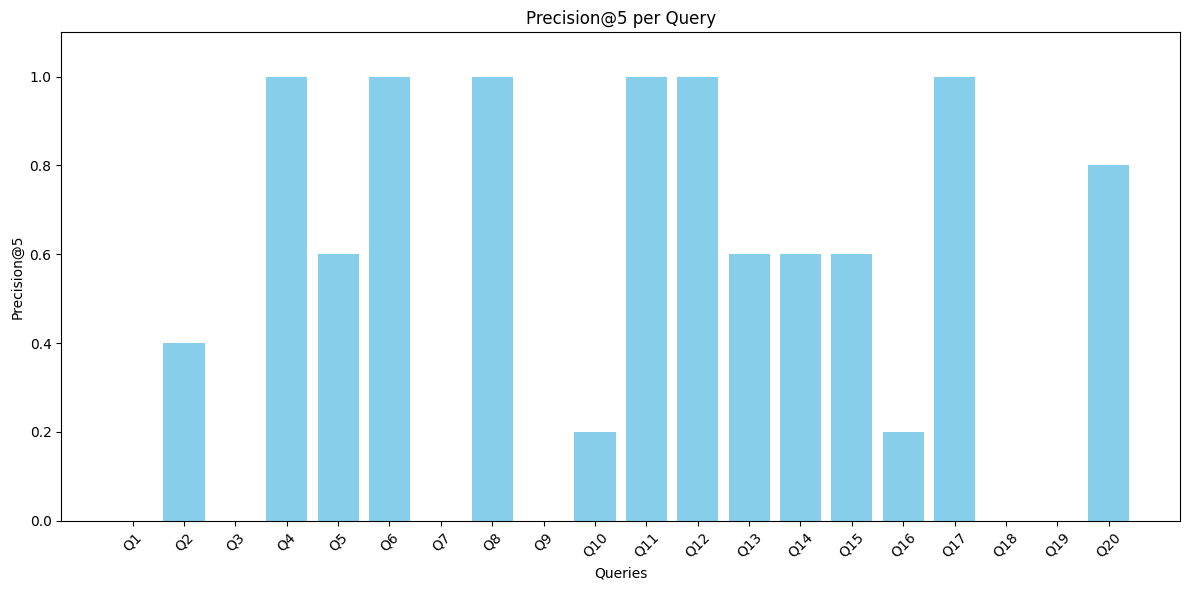

In [14]:
plt.figure(figsize=(12, 6))
plt.bar(queries, precisions, color='skyblue')
plt.title('Precision@5 per Query')
plt.xlabel('Queries')
plt.ylabel('Precision@5')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()